In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

plt.style.use("ggplot")

In [40]:
accident_df = pd.read_csv(
    "../dataset/processed/accident_features.csv"
)

traffic_df = pd.read_csv(
    "../dataset/processed/traffic_features.csv"
)

print("Accident Dataset:", accident_df.shape)
print("Traffic Dataset :", traffic_df.shape)

Accident Dataset: (49932, 30)
Traffic Dataset : (952, 7)


In [41]:
accident_df.head()
traffic_df.head()

,Date,Traffic Volume,Average Speed,Congestion Level,Travel Time Index,Road Capacity Utilization,Traffic_Exposure_Index
0,2022-01-01,35587.666667,40.646202,86.648310,1.449492,92.752653,0.462803
1,2022-01-02,27908.818182,40.920905,76.774305,1.365777,90.354193,0.349594
2,2022-01-03,26660.428571,36.213008,77.038268,1.421750,85.734298,0.331238
3,2022-01-04,29571.636364,39.386708,77.641283,1.365704,92.891541,0.374122
4,2022-01-05,32738.500000,38.791598,82.078308,1.364171,95.074434,0.420824


In [77]:
# Base prior probability
accident_df["Prior_Probability"] = 0.05

# Road condition contribution
accident_df["Prior_Probability"] += (
    accident_df["Road_Risk_Index"] * 0.25
)

# Weather contribution
weather_score = {
    0: 0.00,
    1: 0.10,
    2: 0.20,
    3: 0.30
}

accident_df["Prior_Probability"] += (
    accident_df["Weather"].map(weather_score).fillna(0)
)

# Surface condition contribution
surface_score = {
    0: 0.00,
    1: 0.08,
    2: 0.16,
    3: 0.24
}

accident_df["Prior_Probability"] += (
    accident_df["Surface_Condition"].map(surface_score).fillna(0)
)

# Main cause contribution

main_cause_score = {
    "Human Error": 0.20,
    "Mechanical Defect": 0.18,
    "Overspeeding": 0.25,
    "Drunken Driving": 0.30,
    "Road Defect": 0.22,
    "Weather": 0.15,
    "Not Applicable": 0.05
}

accident_df["Prior_Probability"] += (
    accident_df["Main_Cause"]
    .map(main_cause_score)
    .fillna(0.10)
)
# Clip to valid probability
accident_df["Prior_Probability"] = (
    accident_df["Prior_Probability"]
    .clip(0.05, 0.95)
)

In [78]:
print(
    accident_df[
        [
            "Weather",
            "Road_Condition",
            "Surface_Condition",
            "Road_Type",
            "Main_Cause"
        ]
    ].dtypes
)

Weather              str
Road_Condition       str
Surface_Condition    str
Road_Type            str
Main_Cause           str
dtype: object


In [76]:
print(accident_df["Main_Cause"].dtype)
print(accident_df["Main_Cause"].head())

str
309       Human Error
310       Human Error
311    Not Applicable
312       Human Error
313    Not Applicable
Name: Main_Cause, dtype: str


In [42]:
accident_df = accident_df[
    accident_df["Year"] == 2022
].copy()

print(accident_df.shape)

(5722, 30)


In [44]:
weather_multiplier = {

    "Fine":1.0,

    "Clear":1.0,

    "Cloudy":1.1,

    "Light Rain":1.3,

    "Heavy Rain":1.6,

    "Fog / Mist":1.5,

    "Mist or Fog":1.5,

    "Wind":1.1,

    "Strong Wind":1.3,

    "Very Hot":1.0,

    "Very Cold":1.1,

    "Snow":1.6,

    "Others":1.0,

    "Not Applicable":1.0

}

In [45]:
accident_df["Weather_Multiplier"] = (
    accident_df["Weather"]
    .map(weather_multiplier)
)

accident_df["Weather_Multiplier"] = (
    accident_df["Weather_Multiplier"]
    .fillna(1.0)
)

In [46]:
road_multiplier = {

    "Pot holed":1.8,

    "Engineering Defect of Road":1.7,

    "Construction Work / Material":1.5,

    "Drainage Ditch":1.6,

    "No influence on accident":1.0,

    "Not Applicable":1.0

}

In [47]:
accident_df["Road_Multiplier"] = (
    accident_df["Road_Condition"]
    .map(road_multiplier)
)

accident_df["Road_Multiplier"] = (
    accident_df["Road_Multiplier"]
    .fillna(1.0)
)

In [48]:
surface_multiplier = {

    "Dry":1.0,

    "Wet":1.4,

    "Flooded":1.8,

    "Muddy":1.5,

    "Ditch or Potholed":1.7,

    "Others":1.1,

    "Not Applicable":1.0

}

In [49]:
accident_df["Surface_Multiplier"] = (
    accident_df["Surface_Condition"]
    .map(surface_multiplier)
)

accident_df["Surface_Multiplier"] = (
    accident_df["Surface_Multiplier"]
    .fillna(1.0)
)

In [50]:
accident_df["Posterior_Probability"] = (

    accident_df["Prior_Probability"]

    *

    accident_df["Weather_Multiplier"]

    *

    accident_df["Road_Multiplier"]

    *

    accident_df["Surface_Multiplier"]

)

In [51]:
accident_df["Posterior_Probability"] = (

    accident_df["Posterior_Probability"]

    .clip(upper=0.97)

)

In [52]:
accident_df[
    [
        "Prior_Probability",
        "Weather_Multiplier",
        "Road_Multiplier",
        "Surface_Multiplier",
        "Posterior_Probability"
    ]
].head(20)

,Prior_Probability,Weather_Multiplier,Road_Multiplier,Surface_Multiplier,Posterior_Probability
309,0.01,1.0,1.0,1.0,0.0100
310,0.01,1.0,1.0,1.0,0.0100
311,0.37,1.0,1.6,1.0,0.5920
312,0.01,1.0,1.0,1.0,0.0100
313,0.37,1.1,1.6,1.0,0.6512
314,0.01,1.0,1.0,1.0,0.0100
315,0.01,1.0,1.0,1.0,0.0100
316,0.01,1.0,1.0,1.0,0.0100
317,0.01,1.0,1.0,1.0,0.0100
318,0.01,1.0,1.0,1.0,0.0100


In [53]:
print(traffic_df["Traffic_Exposure_Index"].describe())

count    952.000000
mean       0.370577
std        0.056595
min        0.155924
25%        0.333128
50%        0.370745
75%        0.409491
max        0.540211
Name: Traffic_Exposure_Index, dtype: float64


In [54]:
avg_exposure = traffic_df["Traffic_Exposure_Index"].mean()

accident_df["Traffic_Exposure"] = avg_exposure

print("Average Traffic Exposure:", avg_exposure)

Average Traffic Exposure: 0.37057659087378825


In [55]:
accident_df["Final_Risk"] = (

    accident_df["Posterior_Probability"]

    *

    (

        0.4

        +

        0.6 * accident_df["Traffic_Exposure"]

    )

)

In [56]:
accident_df["Final_Risk"] = (

    accident_df["Final_Risk"]

    .clip(0,1)

)

In [57]:
def classify_risk(score):

    if score < 0.30:
        return "Low"

    elif score < 0.60:
        return "Medium"

    else:
        return "High"

    accident_df["Risk_Level"] = (

    accident_df["Final_Risk"]

    .apply(classify_risk)

)

In [58]:
accident_df["Risk_Level"] = accident_df["Final_Risk"].apply(classify_risk)

In [59]:
print(accident_df["Risk_Level"].value_counts())

Risk_Level
Low       5430
Medium     167
High       125
Name: count, dtype: int64


In [60]:
print("Risk_Level" in accident_df.columns)

True


In [61]:
for col in [
    "Prior_Probability",
    "Posterior_Probability",
    "Traffic_Exposure",
    "Final_Risk",
    "Risk_Level"
]:
    print(col, "->", col in accident_df.columns)


Prior_Probability -> True
Posterior_Probability -> True
Traffic_Exposure -> True
Final_Risk -> True
Risk_Level -> True


In [62]:
accident_df[
    [
        "Prior_Probability",
        "Posterior_Probability",
        "Traffic_Exposure",
        "Final_Risk",
        "Risk_Level"
    ]
].head(20)

,Prior_Probability,Posterior_Probability,Traffic_Exposure,Final_Risk,Risk_Level
309,0.01,0.0100,0.370577,0.006223,Low
310,0.01,0.0100,0.370577,0.006223,Low
311,0.37,0.5920,0.370577,0.368429,Medium
312,0.01,0.0100,0.370577,0.006223,Low
313,0.37,0.6512,0.370577,0.405272,Medium
314,0.01,0.0100,0.370577,0.006223,Low
315,0.01,0.0100,0.370577,0.006223,Low
316,0.01,0.0100,0.370577,0.006223,Low
317,0.01,0.0100,0.370577,0.006223,Low
318,0.01,0.0100,0.370577,0.006223,Low


In [63]:
print(

accident_df["Risk_Level"]

.value_counts()

)

Risk_Level
Low       5430
Medium     167
High       125
Name: count, dtype: int64


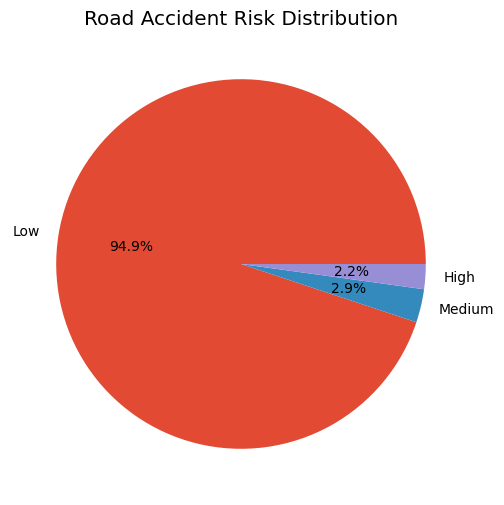

In [64]:
plt.figure(figsize=(6,6))

accident_df["Risk_Level"].value_counts().plot(

    kind="pie",

    autopct="%1.1f%%"

)

plt.ylabel("")

plt.title("Road Accident Risk Distribution")

plt.show()

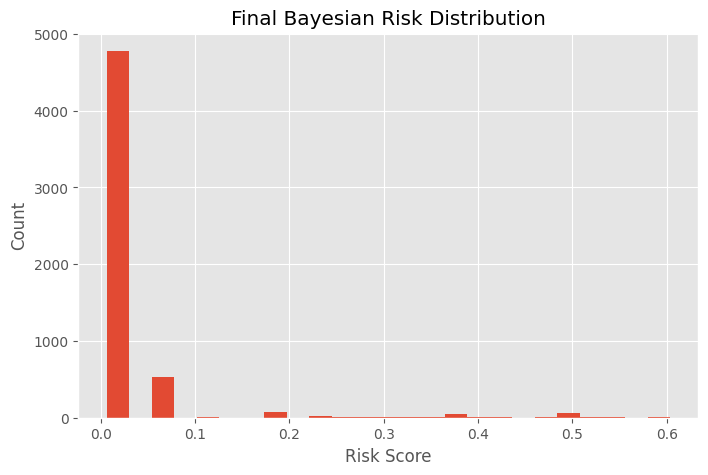

In [65]:
plt.figure(figsize=(8,5))

plt.hist(

    accident_df["Final_Risk"],

    bins=25

)

plt.title("Final Bayesian Risk Distribution")

plt.xlabel("Risk Score")

plt.ylabel("Count")

plt.show()

In [66]:
accident_df["Final_Risk"].describe()

count    5612.000000
mean        0.030651
std         0.084419
min         0.006223
25%         0.006223
50%         0.006223
75%         0.006223
max         0.603676
Name: Final_Risk, dtype: float64

In [67]:
accident_df["Posterior_Probability"].describe()

count    5612.000000
mean        0.049251
std         0.135647
min         0.010000
25%         0.010000
50%         0.010000
75%         0.010000
max         0.970000
Name: Posterior_Probability, dtype: float64

In [68]:
accident_df["Traffic_Exposure"].describe()

count    5.722000e+03
mean     3.705766e-01
std      1.110320e-16
min      3.705766e-01
25%      3.705766e-01
50%      3.705766e-01
75%      3.705766e-01
max      3.705766e-01
Name: Traffic_Exposure, dtype: float64

In [69]:
accident_df["Prior_Probability"].describe()

count    5612.000000
mean        0.036406
std         0.081302
min         0.010000
25%         0.010000
50%         0.010000
75%         0.010000
max         0.450000
Name: Prior_Probability, dtype: float64

In [70]:
traffic_df["Traffic_Exposure_Index"].describe()

count    952.000000
mean       0.370577
std        0.056595
min        0.155924
25%        0.333128
50%        0.370745
75%        0.409491
max        0.540211
Name: Traffic_Exposure_Index, dtype: float64

In [71]:
traffic_df.head()

,Date,Traffic Volume,Average Speed,Congestion Level,Travel Time Index,Road Capacity Utilization,Traffic_Exposure_Index
0,2022-01-01,35587.666667,40.646202,86.648310,1.449492,92.752653,0.462803
1,2022-01-02,27908.818182,40.920905,76.774305,1.365777,90.354193,0.349594
2,2022-01-03,26660.428571,36.213008,77.038268,1.421750,85.734298,0.331238
3,2022-01-04,29571.636364,39.386708,77.641283,1.365704,92.891541,0.374122
4,2022-01-05,32738.500000,38.791598,82.078308,1.364171,95.074434,0.420824


In [72]:
accident_df["Final_Risk"].describe()

count    5612.000000
mean        0.030651
std         0.084419
min         0.006223
25%         0.006223
50%         0.006223
75%         0.006223
max         0.603676
Name: Final_Risk, dtype: float64

In [73]:
accident_df["Prior_Probability"].value_counts().head(10)

Prior_Probability
0.01    4777
0.10     539
0.45     112
0.37      75
0.19      67
0.28      42
Name: count, dtype: int64

In [74]:
accident_df["Posterior_Probability"].value_counts().head(10)


Posterior_Probability
0.010    4514
0.110     507
0.011     143
0.015      97
0.810      59
0.285      56
0.592      41
0.121      19
0.392      15
0.970      15
Name: count, dtype: int64

In [79]:
print(accident_df["Weather"].value_counts())

Weather
Clear                            2787
Fine                             1937
Others                            524
Cloudy                            176
Not Applicable                     98
Fog / Mist                         87
Light Rain                         20
Mist or Fog                        20
Hail or Sleet                      17
Very Cold                          13
Snow                               11
Very Hot                           10
Dust Storn                          6
Heavy Rain                          6
Wind                                5
Flooding of Slipways/Rivulets       4
Strong Wind                         1
Name: count, dtype: int64


In [80]:
print(accident_df["Road_Condition"].value_counts())

Road_Condition
Not Applicable                  3922
No influence on accident        1592
Construction Work / Material      82
Pot holed                         65
Drainage Ditch                    48
Engineering Defect of Road        13
Name: count, dtype: int64


In [81]:
print(accident_df["Surface_Condition"].value_counts())

Surface_Condition
Dry                  4800
Others                597
Not Applicable        248
Muddy                  27
Wet                    24
Ditch or Potholed      19
Flooded                 7
Name: count, dtype: int64


In [82]:
print(accident_df["Road_Type"].value_counts())

Road_Type
Others                 1897
NH                     1255
Two way                 644
State Highway           479
Residential Street      324
One way                 223
Sub Arterial            193
Arterial                184
Not Applicable          159
Service Road            110
Major District Road      83
Expressway               69
Minor District Road      61
Mixed                    23
Feeder Road              13
Forest Road               5
Name: count, dtype: int64


In [83]:
print(accident_df["Main_Cause"].value_counts())

Main_Cause
Human Error                4587
Not Applicable              953
Vehicle Defect              169
Road Environment Defect      13
Name: count, dtype: int64
